# Sum (100)

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import copy
from IPython.display import Image
from qutip import *
import time

import pickle

In [5]:
dim = 2      # number of levels for each qubit
GHz = 1e8    #1e9 (0.1GHz)
ns = 1e-9
b = destroy(dim)                     # sigma minus operator

s0m = tensor(b, qeye(dim))           # sigma minus on 0
s0p = tensor(b.dag(), qeye(dim))     # sigma plus on 0
s1m = tensor(qeye(dim), b)           # sigma minus on 1
s1p = tensor(qeye(dim), b.dag())     # sigma plus on 1

omega = [2*np.pi*5.0*GHz, 2*np.pi*5.2*GHz]            # qubit transition frequencies [rad/s]
Delta = [2*np.pi*0*GHz,2*np.pi*0*GHz] #[-.33, -.33]   # anharmonicities [rad/s]
Omega = [2*np.pi*1*GHz, 2*np.pi*1.1*GHz]              # control-qubit drive strength [rad/s]
J = 2*np.pi*0.3*GHz                                     # passive interaction [rad/s]

c_max = 10  # upper bound for control amplitudes
c_min = -10   # lower bound for control amplitudes
T = 10*ns   # target time
L = 10     # number of piecewise constants (at most 20)

H0 = ( omega[0]*s0p*s0m + omega[1]*s1p*s1m ) + \
     (1/2)*( Delta[0]*s0p*s0p*s0m*s0m + Delta[1]*s1p*s1p*s1m*s1m ) + \
     J*(s0p*s1m+s0m*s1p)

Hc0m = Omega[0]*(s0m) # control Hamiltonian operators proportional to raising and lowering ops
Hc1m = Omega[1]*(s1m)
Hc0p = Omega[0]*(s0p)
Hc1p = Omega[1]*(s1p)

# Piecewise Constant Control on qubit 0
def C0(t, args):
    c = args['c']     # list of control parameters [c11,...,c1L]
    T = args['T']     # target time 
    L = args['L']     # L pieces
    t_inv = list(np.linspace(0,T,L+1))     # endpoints of time interval
    return( np.sum([c[0][i] * ( float(t>=t_inv[i] and t<t_inv[i+1]) ) for i in range(L)])+c[0][L-1]*float(t==t_inv[L])  )

def C1(t, args):
    c = args['c']     # list of control parameters [c21,...,c2L]
    T = args['T']     # target time 
    L = args['L']     # L pieces
    t_inv = list(np.linspace(0,T,L+1))     # endpoints of time interval
    return( np.sum([c[1][i] * ( float(t>=t_inv[i] and t<t_inv[i+1]) ) for i in range(L)])+c[1][L-1]*float(t==t_inv[L])  )

# Piecewise Constant Control on qubit 1
def C2(t, args):
    c = args['c']     # list of control parameters [c31,...,c3L]
    T = args['T']     # target time 
    L = args['L']     # L pieces
    t_inv = list(np.linspace(0,T,L+1))     # endpoints of time interval
    return( np.sum([c[2][i] * ( float(t>=t_inv[i] and t<t_inv[i+1]) ) for i in range(L)])+c[2][L-1]*float(t==t_inv[L])  )

def C3(t, args):
    c = args['c']     # list of control parameters [c41,...,c4L]
    T = args['T']     # target time 
    L = args['L']     # L pieces
    t_inv = list(np.linspace(0,T,L+1))     # endpoints of time interval
    return( np.sum([c[3][i] * ( float(t>=t_inv[i] and t<t_inv[i+1]) ) for i in range(L)])+c[3][L-1]*float(t==t_inv[L])  )

# Marker
def ep0(t, args):
    omega = args['omega']
    return np.exp(1j *omega[0]*t)

def em0(t, args):
    omega = args['omega']
    return np.exp(-1j *omega[0]*t)

def ep1(t, args):
    omega = args['omega']
    return np.exp(1j *omega[1]*t)

def em1(t, args):
    omega = args['omega']
    return np.exp(-1j *omega[1]*t)

# Control Functions C_i_j_k: i=0,1; j=m,p related to sm/sp; k=m,p related to (sm-sp) or (sm+sp)
def C0mm(t, args):
    return 1j*C0(t, args)*ep0(t, args)
def C0pm(t, args):
    return -1j*C0(t, args)*em0(t, args)

def C0mp(t, args):
    return C1(t, args)*ep0(t, args)
def C0pp(t, args):
    return C1(t, args)*em0(t, args)

def C1mm(t, args):
    return 1j*C2(t, args)*ep1(t, args)
def C1pm(t, args):
    return -1j*C2(t, args)*em1(t, args)

def C1mp(t, args):
    return C3(t, args)*ep1(t, args)
def C1pp(t, args):
    return C3(t, args)*em1(t, args)

# Total Hamiltonain
H = [H0, [Hc0m,C0mm], [Hc0p,C0pm], [Hc0m,C0mp], [Hc0p,C0pp], [Hc1m,C1mm], [Hc1p,C1pm], [Hc1m,C1mp], [Hc1p,C1pp]]   

In [6]:
GA = sigmax() # Target Unitary on qubit 0
GB = sigmax() # Target Unitary on qubit 1

In [7]:
def OBJ(c,T,L,omega,H,GA,GB):
    
    args = {
        'c': c,
        'T': T,
        'L': L,
        'omega': omega
    }
    
    U = propagator(H, T, args=args,options=Options(nsteps=1700))
    
    # SVD for partial traces
    sigma = np.sqrt((((tensor(GA,qeye(dim)).dag()*U).ptrace(1))*((tensor(GA,qeye(dim)).dag()*U).ptrace(1)).dag()).eigenstates()[0])
    lambd = np.sqrt((((tensor(qeye(dim),GB).dag()*U).ptrace(0))*((tensor(qeye(dim),GB).dag()*U).ptrace(0)).dag()).eigenstates()[0])
    
    # sum of fidelity
    return sum(sigma)/(2*dim**2)+sum(lambd)/(2*dim**2)

In [1]:
# GRadient Ascent Pulse Engineering (GRAPE)

def GRAPE(T,L,omega,H,GA,GB):
    eps = 0.01  # ascending rate
    threshold = 0.00001  # if cost changes less than threshold, then halt
    itera_max = 1000     # max iteration number
    count = 0           # counting iterations
    diff_cost = np.inf  # initial cost difference
    d = T/L             # time interval length
    record_cost = []
    factor = 0.1

    # Step1-1, Guess initial
    c = [[float(np.random.uniform(c_min,c_max)) for _ in range(L)],    # for C1
         [float(np.random.uniform(c_min,c_max)) for _ in range(L)],    # for C2
         [float(np.random.uniform(c_min,c_max)) for _ in range(L)],    # for C3
         [float(np.random.uniform(c_min,c_max)) for _ in range(L)]]    # for C4

    # Step1-2, Compute initial cost
    cost = OBJ(c,T,L,omega,H,GA,GB)
    record_cost.append(cost)


    # Start while loop
    while (count<=itera_max) and (diff_cost>threshold):   
        count += 1
    
        # Step 2, compute derivative numerically by Df(x0) = (f(x0+dx)-f(x0)) / dx
        dx = 0.1*factor
        D_J_c = [ [ 0 for l in range(L)] for m in range(4)]
        for m in range(4):
            for l in range(L):
                c_tmp = copy.deepcopy(c)
                c_tmp[m][l] += dx
                D_J_c[m][l] += (OBJ(c_tmp,T,L,omega,H,GA,GB) - OBJ(c,T,L,omega,H,GA,GB)) / dx
    
        # Step 3, normalization for gradient
        norm2_D = 0
        for m in range(4):
            for l in range(L):
                norm2_D += D_J_c[m][l]**2
            
        norm_D = np.sqrt(norm2_D)
        if (not np.isfinite(norm_D)) or norm_D < 1e-12:
            print("Gradient norm is zero or invalid. Stopping this trial.")
            return record_cost, c
    
        D_J_c = [[ eps*D_J_c[m][l]/norm_D for l in range(L)] for m in range(4)]
    
        # Step4, gradient ascend
        c = np.array(c) + np.array(D_J_c)    
     
    
        # Step5, Compute cost 
        new_cost = OBJ(c,T,L,omega,H,GA,GB)
        diff_cost = abs(new_cost - record_cost[-1])
        if new_cost > record_cost[-1]:
            record_cost.append(new_cost)
            eps = min(eps+0.1*factor,0.9*factor)   # set upper bound for the learning rate
        else:
            eps = 0.1*factor
            factor *= 0.1

    return record_cost, c
    

In [8]:
# Faster GRAPE Replacement

from scipy.linalg import expm, expm_frechet
from scipy.optimize import minimize


GRAPE_OPTIMIZER = "lbfgsb"     # "lbfgsb" or "ascent"
GRAPE_RECORD_MODE = "trace"    # "trace" or "sum"

# "trace" = standard gate fidelity objective:
#     |Tr(U_target^\dagger U)|^2 / D^2
#
# "sum" = your original partial-trace / singular-value objective.

# Convert QuTiP Qobj or numpy array to complex numpy array.
def to_np(A):
    if hasattr(A, "full"):
        return np.array(A.full(), dtype=complex)
    return np.array(A, dtype=complex)


def extract_control_ops_from_H(H):
    # H[0]    = H0
    # H[1][0] = Hc0m
    # H[2][0] = Hc0p
    # H[5][0] = Hc1m
    # H[6][0] = Hc1p
    
    H0 = H[0]
    Hc0m = H[1][0]
    Hc0p = H[2][0]
    Hc1m = H[5][0]
    Hc1p = H[6][0]

    return map(to_np, [H0, Hc0m, Hc0p, Hc1m, Hc1p])

# Partial trace objective
def ptrace_operator_two_qubit(M, keep, d=2):
    M4 = M.reshape(d, d, d, d)

    if keep == 0:
        # result[a,c] = sum_b M[a,b,c,b]
        return np.einsum("abcb->ac", M4)

    elif keep == 1:
        # result[b,d] = sum_a M[a,b,a,d]
        return np.einsum("abad->bd", M4)

    else:
        raise ValueError("keep must be 0 or 1")

# original sum objective structure
def original_sum_objective_from_U(U, GA_np, GB_np):
    d = GA_np.shape[0]
    I = np.eye(d, dtype=complex)

    A_full = np.kron(GA_np, I).conj().T @ U
    B_full = np.kron(I, GB_np).conj().T @ U

    A = ptrace_operator_two_qubit(A_full, keep=1, d=d)
    B = ptrace_operator_two_qubit(B_full, keep=0, d=d)

    sigma = np.linalg.svd(A, compute_uv=False)
    lambd = np.linalg.svd(B, compute_uv=False)
    
    # max = 1
    return np.real(np.sum(sigma) / (2 * d**2) + np.sum(lambd) / (2 * d**2))

# standard phase-insensitive gate fidelity objective
def trace_gate_objective_from_U(U, U_target):
    # max = 1
    D = U.shape[0]
    z = np.trace(U_target.conj().T @ U)
    return np.real(np.abs(z)**2 / D**2)

# ------------------------------------------------------------
# Time-slice Hamiltonian construction
# ------------------------------------------------------------

def control_ops_at_time(t, omega, Hc0m, Hc0p, Hc1m, Hc1p):
    """
    Build the four effective control operators at time t,
    corresponding to the four real controls C0, C1, C2, C3.

    Qubit 0:
        C0(t):  i e^{+i w0 t} Hc0m - i e^{-i w0 t} Hc0p
        C1(t):    e^{+i w0 t} Hc0m +   e^{-i w0 t} Hc0p

    Qubit 1:
        C2(t):  i e^{+i w1 t} Hc1m - i e^{-i w1 t} Hc1p
        C3(t):    e^{+i w1 t} Hc1m +   e^{-i w1 t} Hc1p
    """
    w0, w1 = omega[0], omega[1]

    e0p = np.exp(1j * w0 * t)
    e0m = np.exp(-1j * w0 * t)

    e1p = np.exp(1j * w1 * t)
    e1m = np.exp(-1j * w1 * t)

    Hctrl0 = 1j * e0p * Hc0m - 1j * e0m * Hc0p
    Hctrl1 = e0p * Hc0m + e0m * Hc0p

    Hctrl2 = 1j * e1p * Hc1m - 1j * e1m * Hc1p
    Hctrl3 = e1p * Hc1m + e1m * Hc1p

    return [Hctrl0, Hctrl1, Hctrl2, Hctrl3]


def build_slice_data(H0, c, T, omega, Hc0m, Hc0p, Hc1m, Hc1p):
    """
    Build H_ell, U_ell, and dH_ell/dc[m,ell] for every time slice.
    Instead of using QuTiP's propagator, we uses the fact that
    controls are piecewise constant.

    For each slice:
        H_ell = H0 + sum_m c[m,ell] H_m(t_mid)
        U_ell = exp(-i H_ell dt)

    The oscillatory factors are evaluated at the midpoint of each interval.
    """
    n_controls, L = c.shape
    dt = T / L

    H_slices = []
    U_slices = []
    control_ops_slices = []

    for ell in range(L):
        t_mid = (ell + 0.5) * dt

        H_controls = control_ops_at_time(
            t_mid, omega, Hc0m, Hc0p, Hc1m, Hc1p
        )

        H_ell = H0.copy()
        for m in range(n_controls):
            H_ell = H_ell + c[m, ell] * H_controls[m]

        U_ell = expm(-1j * H_ell * dt)

        H_slices.append(H_ell)
        U_slices.append(U_ell)
        control_ops_slices.append(H_controls)

    return H_slices, U_slices, control_ops_slices


def forward_backward_products(U_slices):
    """
    Compute forward and backward products.

    Full evolution:
        U(T) = U_{L-1} ... U_1 U_0

    F[ell] = U_ell ... U_0
    B[ell] = U_{L-1} ... U_{ell+1}

    Therefore, U(T) = B[ell] @ U_ell @ F[ell-1]
    """
    L = len(U_slices)
    D = U_slices[0].shape[0]

    F = [None] * L
    B = [None] * L

    current = np.eye(D, dtype=complex)
    for ell in range(L):
        current = U_slices[ell] @ current
        F[ell] = current

    current = np.eye(D, dtype=complex)
    for ell in reversed(range(L)):
        B[ell] = current
        current = current @ U_slices[ell]

    U_final = F[-1]

    return U_final, F, B

# Fast piecewise-constant propagation.
def propagate_fast(c, T, omega, H0, Hc0m, Hc0p, Hc1m, Hc1p):
    H_slices, U_slices, control_ops_slices = build_slice_data(
        H0, c, T, omega, Hc0m, Hc0p, Hc1m, Hc1p
    )
    U_final, F, B = forward_backward_products(U_slices)
    return U_final, H_slices, U_slices, control_ops_slices, F, B


# Public OBJ function
def OBJ(c, T, L, omega, H, GA, GB):
    # using the fast piecewise-constant propagator instead of QuTiP propagator
    H0, Hc0m, Hc0p, Hc1m, Hc1p = extract_control_ops_from_H(H)

    GA_np = to_np(GA)
    GB_np = to_np(GB)

    c = np.array(c, dtype=float).reshape(4, L)

    U, _, _, _, _, _ = propagate_fast(
        c, T, omega, H0, Hc0m, Hc0p, Hc1m, Hc1p
    )
    return original_sum_objective_from_U(U, GA_np, GB_np)

# Analytic GRAPE objective and gradient
def trace_objective_and_gradient(c, T, omega, H0, Hc0m, Hc0p, Hc1m, Hc1p, U_target):
    """
    Compute standard trace gate fidelity and analytic GRAPE gradient.
    Objective:
        J = |Tr(U_target^\dagger U)|^2 / D^2
    Gradient:
        Uses the Frechet derivative of exp(-i H_ell dt).
    """
    n_controls, L = c.shape
    dt = T / L

    U, H_slices, U_slices, control_ops_slices, F, B = propagate_fast(
        c, T, omega, H0, Hc0m, Hc0p, Hc1m, Hc1p
    )

    D = U.shape[0]

    z = np.trace(U_target.conj().T @ U)
    J = np.real(np.abs(z)**2 / D**2)

    grad = np.zeros_like(c, dtype=float)

    for ell in range(L):
        F_before = np.eye(D, dtype=complex) if ell == 0 else F[ell - 1]

        H_ell = H_slices[ell]
        A = -1j * H_ell * dt

        for m in range(n_controls):
            dH = control_ops_slices[ell][m]
            E = -1j * dH * dt

            # Exact derivative of exp(A) in direction E
            dU_ell = expm_frechet(A, E, compute_expm=False)

            # Chain into full propagator:
            # dU(T) = B_ell dU_ell F_{ell-1}
            dU_total = B[ell] @ dU_ell @ F_before

            dz = np.trace(U_target.conj().T @ dU_total)

            # dJ = 2 Re(conj(z) dz) / D^2
            grad[m, ell] = 2 * np.real(np.conj(z) * dz) / D**2

    return J, grad, U


def GRAPE(T, L, omega, H, GA, GB):
    c_min = -10.0
    c_max = 10.0

    max_iter = 300
    step_size = 0.1
    tol = 1e-8

    # Convert everything to numpy
    H0, Hc0m, Hc0p, Hc1m, Hc1p = extract_control_ops_from_H(H)

    GA_np = to_np(GA)
    GB_np = to_np(GB)

    U_target = np.kron(GA_np, GB_np)

    # Random initial pulse
    c = np.random.uniform(c_min, c_max, size=(4, L))

    record_cost = []

    # Option 1: L-BFGS-B optimizer
    if GRAPE_OPTIMIZER == "lbfgsb":

        def loss_and_grad(theta):
            c_now = theta.reshape(4, L)

            J_trace, grad, U = trace_objective_and_gradient(
                c_now, T, omega, H0, Hc0m, Hc0p, Hc1m, Hc1p, U_target
            )

            if GRAPE_RECORD_MODE == "sum":
                J_record = original_sum_objective_from_U(U, GA_np, GB_np)
            else:
                J_record = J_trace

            record_cost.append(float(J_record))

            # scipy minimizes, so minimize -J
            return -J_trace, -grad.reshape(-1)

        bounds = [(c_min, c_max)] * (4 * L)

        result = minimize(
            fun=lambda theta: loss_and_grad(theta),
            x0=c.reshape(-1),
            jac=True,
            bounds=bounds,
            method="L-BFGS-B",
            options={
                "maxiter": max_iter,
                "ftol": 1e-12,
                "gtol": 1e-8,
                "maxls": 30,
                "disp": False,
            },
        )

        c_opt = result.x.reshape(4, L)

        return record_cost, c_opt

    # Option 2: Normalized analytic gradient ascent
    elif GRAPE_OPTIMIZER == "ascent":

        previous_cost = None

        for it in range(max_iter):

            J_trace, grad, U = trace_objective_and_gradient(
                c, T, omega, H0, Hc0m, Hc0p, Hc1m, Hc1p, U_target
            )

            if GRAPE_RECORD_MODE == "sum":
                J_record = original_sum_objective_from_U(U, GA_np, GB_np)
            else:
                J_record = J_trace

            record_cost.append(float(J_record))

            if previous_cost is not None:
                if abs(J_record - previous_cost) < tol:
                    break

            previous_cost = J_record

            grad_norm = np.linalg.norm(grad)

            if not np.isfinite(grad_norm) or grad_norm < 1e-14:
                break

            c = c + step_size * grad / grad_norm
            c = np.clip(c, c_min, c_max)

        return record_cost, c

    else:
        raise ValueError("GRAPE_OPTIMIZER must be 'lbfgsb' or 'ascent'")

<>:207: SyntaxWarning: invalid escape sequence '\d'
<>:207: SyntaxWarning: invalid escape sequence '\d'
/var/folders/cv/65pqnbr131v9dp06nl45s8n80000gn/T/ipykernel_66108/584196780.py:207: SyntaxWarning: invalid escape sequence '\d'
  """


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


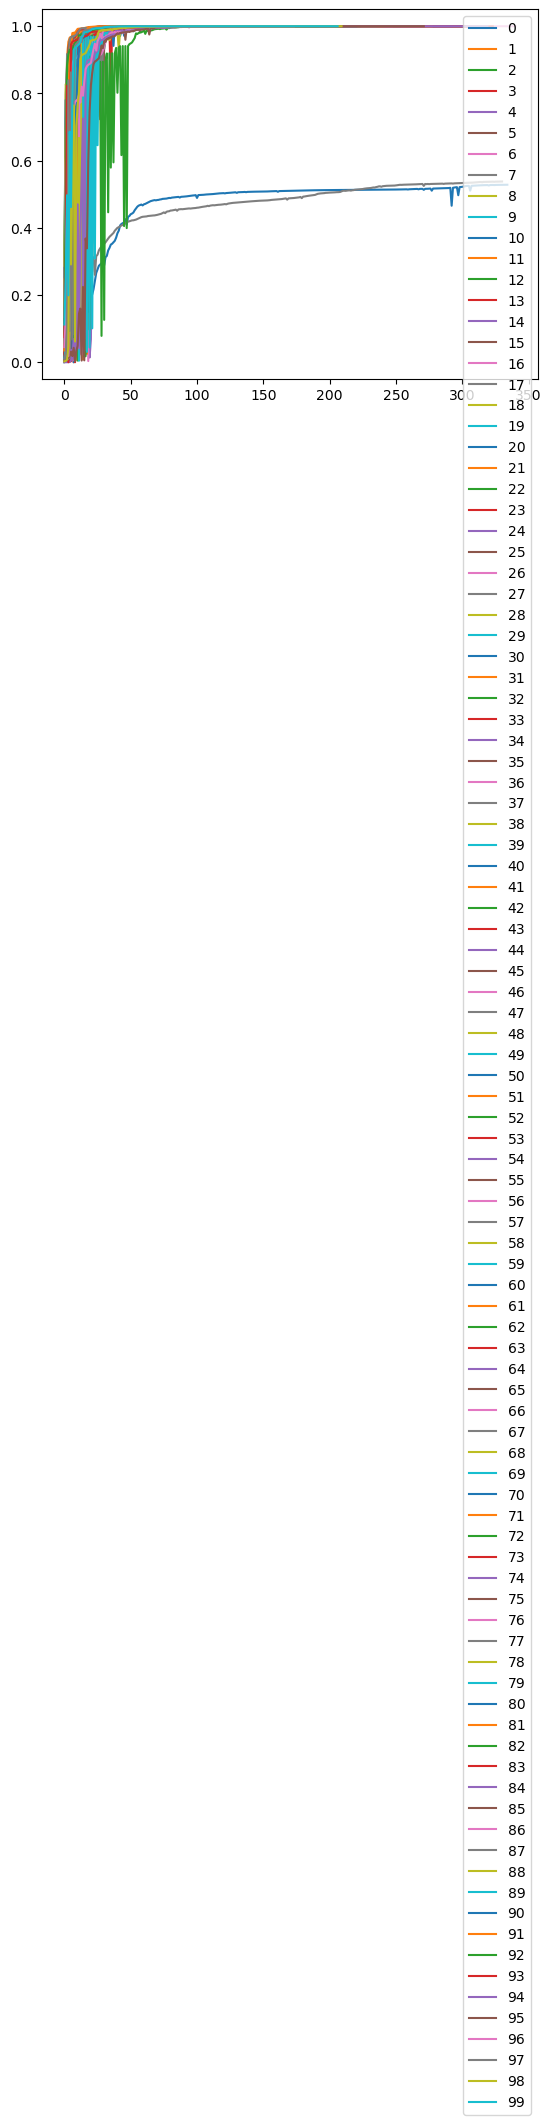

154.34647393226624


In [9]:
record_c = []
record_f = {}
n_trails = 100
start_time = time.time()
for i in range(n_trails): # apply GRAPE with random initial multiple times
    print(i)
    fidelity,c = GRAPE(T,L,omega,H,GA,GB)
    record_c.append(c)
    record_f.update({i:fidelity})
    with open("2023_GRAPE_sum.bin", "wb") as f:
        pickle.dump([record_c, record_f], f)
    plt.plot(fidelity)
    
end_time = time.time()
plt.legend([str(i) for i in range(n_trails)])
plt.show()
print(end_time-start_time)

In [13]:
print(end_time)

1698028166.436561


2
[155, 252, 216, 243, 236, 192, 227, 174, 170, 238, 241, 164, 304, 225, 203, 264, 271, 320, 241, 186, 227, 277, 206, 212, 166, 164, 235, 225, 242, 264, 207, 152, 223, 205, 182, 228, 228, 202, 198, 203, 231, 209, 211, 307, 206, 198, 341, 230, 176, 158, 268, 231, 191, 193, 254, 216, 184, 312, 231, 164, 236, 200, 205, 192, 232, 239, 249, 248, 219, 195, 251, 324, 293, 238, 248, 279, 277, 236, 212, 213, 224, 166, 204, 185, 278, 202, 241, 199, 221, 179, 192, 307, 320, 272, 174, 206, 210, 207]
225.0204081632653
41.36990417274343
[335, 331]
333.0
2.0


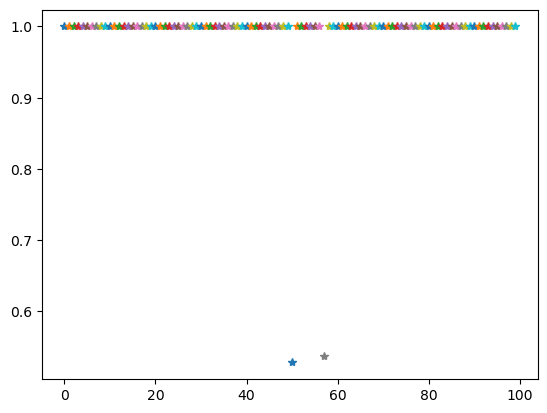

In [10]:
with open("2023_GRAPE_sum.bin", "rb") as f:
    rec_c, rec_f= pickle.load(f)

lists = sorted(rec_f.items())
x, y = zip(*lists) 
count = 0
conv_u = []
conv_l = []

for i in range(n_trails):
    p_y = y[i]
    if p_y[-1]<0.8:
        count += 1
        conv_l.append(len(p_y))
    else:
        conv_u.append(len(p_y))
    plt.plot(x[i],p_y[-1],'*')
    
print(count)
print(conv_u)
print(np.mean(conv_u))
print(np.std(conv_u))
print(conv_l)
print(np.mean(conv_l))
print(np.std(conv_l))